2026-03-21 16:28:26.879196: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774110507.188858      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774110507.276481      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774110508.028548      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774110508.028592      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774110508.028595      55 computation_placer.cc:177] computation placer alr


Đang tải dữ liệu Test và Mô hình...


2026-03-21 16:29:01.121704: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


✅ Load mô hình thành công!

📊 ĐÁNH GIÁ BẰNG KERAS METRICS:
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 248ms/step - accuracy: 0.8878 - auc: 0.9475 - loss: 0.3184 - precision: 0.9314 - recall: 0.7762
 - Loss: 0.3370
 - Compile_metrics: 0.8790

Đang dự đoán trên tập test...
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 597ms/step

BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT):
                 precision    recall  f1-score   support

Bình thường (0)       0.88      0.94      0.91       905
     Té ngã (1)       0.90      0.81      0.85       582

       accuracy                           0.89      1487
      macro avg       0.89      0.87      0.88      1487
   weighted avg       0.89      0.89      0.89      1487



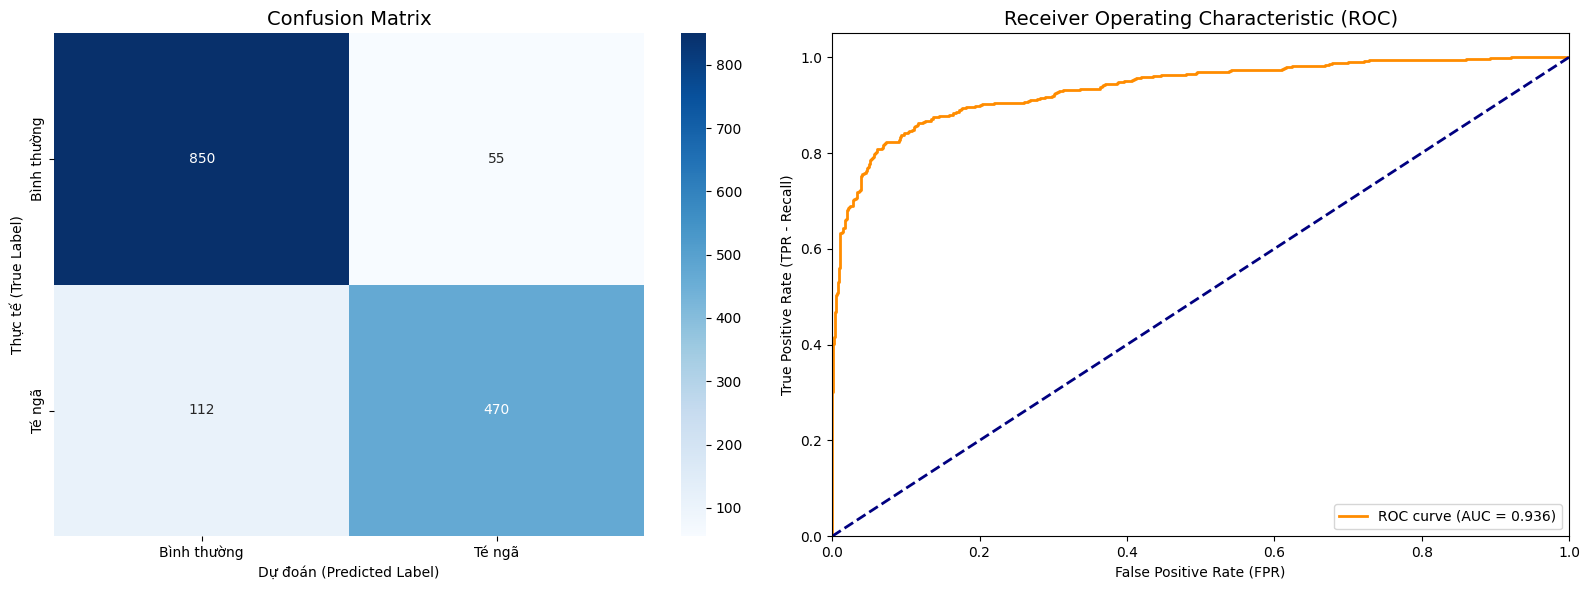


✅ Hoàn tất! Đã lưu biểu đồ đánh giá tại /kaggle/working/evaluation_results.png


In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# ==========================================
# 1. THIẾT LẬP GPU VÀ MÔI TRƯỜNG
# ==========================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print("✅ Đang sử dụng GPU để đánh giá.")
    # Bật Mixed Precision cho giống lúc train
    policy = tf.keras.mixed_precision.Policy('mixed_float16')
    tf.keras.mixed_precision.set_global_policy(policy)

# ==========================================
# 2. KHAI BÁO ĐƯỜNG DẪN (QUAN TRỌNG: BẠN CẦN KIỂM TRA LẠI)
# ==========================================
# Dựa vào ảnh của bạn, model nằm trong dataset "DuLieuTest"
MODEL_PATH = "/kaggle/input/datasets/huuthang8686/dulieutest2/best_bilstm_model.h5" 

# LƯU Ý: Bạn cần thay đổi DATA_DIR trỏ tới nơi chứa file X_test.npy và y_test.npy
DATA_DIR = "/kaggle/input/datasets/huuthang8686/dulieutrain/processed_data" # Đổi lại nếu cần

print("\nĐang tải dữ liệu Test và Mô hình...")
X_test = np.load(f"{DATA_DIR}/X_test.npy")
y_test = np.load(f"{DATA_DIR}/y_test.npy")

# ==========================================
# 3. LOAD MÔ HÌNH VÀ ĐÁNH GIÁ CƠ BẢN
# ==========================================
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Load mô hình thành công!")

# Dùng tf.data để load nhanh hơn
BATCH_SIZE = 256
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("\n📊 ĐÁNH GIÁ BẰNG KERAS METRICS:")
results = model.evaluate(test_dataset, verbose=1)

# In kết quả cho dễ nhìn
metric_names = model.metrics_names
for name, val in zip(metric_names, results):
    print(f" - {name.capitalize()}: {val:.4f}")

# ==========================================
# 4. PREDICT ĐỂ TÍNH TOÁN CHI TIẾT (SCIKIT-LEARN)
# ==========================================
print("\nĐang dự đoán trên tập test...")
y_pred_probs = model.predict(test_dataset)
y_pred_classes = (y_pred_probs > 0.4).astype(int).flatten() 

print("\nBÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT):")
print(classification_report(y_test, y_pred_classes, target_names=['Bình thường (0)', 'Té ngã (1)']))

# ==========================================
# 5. VẼ BIỂU ĐỒ TRỰC QUAN (CONFUSION MATRIX & ROC CURVE)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- A. Ma trận nhầm lẫn (Confusion Matrix) ----
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Bình thường', 'Té ngã'], 
            yticklabels=['Bình thường', 'Té ngã'])
axes[0].set_title('Confusion Matrix', fontsize=14)
axes[0].set_ylabel('Thực tế (True Label)')
axes[0].set_xlabel('Dự đoán (Predicted Label)')

# ---- B. Đường cong ROC (ROC Curve) ----
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR - Recall)')
axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=14)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig('/kaggle/working/evaluation_results.png', dpi=300)
plt.show()

print("\n✅ Hoàn tất! Đã lưu biểu đồ đánh giá tại /kaggle/working/evaluation_results.png")